In [39]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
from dotenv import load_dotenv
from qbstyles import mpl_style
import pytidycensus as tc
from concurrent.futures import ThreadPoolExecutor
from typing import Dict, Literal, List, Union
import glob
import warnings
from pygris import counties
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")


%config InlineBackend.figure_format = 'retina'

mpl_style(dark=True)

load_dotenv()

API_KEY: str = os.getenv("CENSUS_KEY")
DATA: str = os.getenv("DATA")

tc.set_census_api_key(API_KEY)

pd.set_option('display.precision', 2)



Census API key has been set for this session.


# Data Collection

## RUCC

::: {.callout-note}
### Overview
The 2023 Rural-Urban Continuum Codes distinguish U.S. metropolitan (metro) counties by the population size of their metro area, and nonmetropolitan (nonmetro) counties by their degree of urbanization and adjacency to a metro area. The division of counties as either metro or nonmetro, based on the 2023 Office of Management and Budget (OMB) delineation of metro areas, is further subdivided into three metro and six nonmetro categories. Each county and census-designated county-equivalent in the United States, including those in outlying territories, is assigned one of these nine codes. The codes allow researchers, policy makers, and others to view county-level data by finer residential groups—beyond metro and nonmetro—when analyzing trends related to population density and metro influence.

*See: [USDA Rural-Urban Continuum Codes Overview](https://www.ers.usda.gov/data-products/rural-urban-continuum-codes) for more information and the [Center for Rural Policy and Development](https://www.ruralmn.org/an-update-to-rural-urban-continuum-codes/) article on the implications of the new RUCC codes*
:::

In [21]:
# | label: tbl-rural-codes
# | tbl-cap: "Rural-Urban Continuum Codes"

data = {
    "Code": [1, 2, 3, 4, 5, 6, 7, 8, 9],
    "Description": [
        "Counties in metro areas of 1 million population or more",
        "Counties in metro areas of 250,000 to 1 million population",
        "Counties in metro areas of fewer than 250,000 population",
        "Urban population of 20,000 or more, adjacent to a metro area",
        "Urban population of 20,000 or more, not adjacent to a metro area",
        "Urban population of 5,000 to 20,000, adjacent to a metro area",
        "Urban population of 5,000 to 20,000, not adjacent to a metro area",
        "Urban population of fewer than 5,000, adjacent to a metro area",
        "Urban population of fewer than 5,000, not adjacent to a metro area",
    ],
    "Category": ["Metropolitan"] * 3 + ["Nonmetropolitan"] * 6,
}

df = pd.DataFrame(data)

df


,Code,Description,Category
0,1,Counties in metro areas of 1 million populatio...,Metropolitan
1,2,"Counties in metro areas of 250,000 to 1 millio...",Metropolitan
2,3,"Counties in metro areas of fewer than 250,000 ...",Metropolitan
3,4,"Urban population of 20,000 or more, adjacent t...",Nonmetropolitan
4,5,"Urban population of 20,000 or more, not adjace...",Nonmetropolitan
5,6,"Urban population of 5,000 to 20,000, adjacent ...",Nonmetropolitan
6,7,"Urban population of 5,000 to 20,000, not adjac...",Nonmetropolitan
7,8,"Urban population of fewer than 5,000, adjacent...",Nonmetropolitan
8,9,"Urban population of fewer than 5,000, not adja...",Nonmetropolitan


### Data

In [22]:
def collect_rucc_data(data_path: str) -> pd.DataFrame:
    data = pd.read_csv(f"{data_path}/RUCC.csv")
    data.drop(columns=["Population_2020", "Description"], inplace=True)
    data.rename(columns={"RUCC_2023": "RUCC"}, inplace=True)
    data["County_Name"] = (
        data["County_Name"].str.replace("County", "").str.strip().str.lower()
    )
    data["County_Name"] = (
        data["County_Name"].str.replace("Parish", "").str.strip().str.lower()
    )

    data.rename(
        columns={"FIPS": "GEOID"},
        inplace=True,
    )

    return data


rucc = collect_rucc_data(data_path=DATA)
rucc.head()


,GEOID,State,County_Name,RUCC
0,1001,AL,autauga,2.0
1,1003,AL,baldwin,3.0
2,1005,AL,barbour,6.0
3,1007,AL,bibb,1.0
4,1009,AL,blount,1.0


- `GEOID`: State & County identifier
- `state`: State abbreviation
- `county`: Name of county
- `RUCC`: RUCC of county

# American Community Survey Data

## Overview

- ACS data are collected for three years: 2013, 2018, and 2023.
    - The Census Bureau highly discourages comparing data from years within the same 5-year time period due to the way the 5-year ACS data is collected and constructed, so these are the ideal years to use for a time-series comparison that includes the demographic and socio-economic variables available through the ACS.
- **Race and Total Population Variables**: Individual race variables will be scaled to the total population so that each variable represents the percentage of the population in a county that identifies as each race.
    - Helps reduce the effect of population differences.
- **Median Earnings, Poverty, and Gini Index**: these variables are to reflect the economic conditions in each census tract without going overboard.
    - Total number of people under the poverty level will be scaled by the total population to reflect the poverty rate.
- **Note**: Margin of error columns are dropped becayse pytidycensus handles it at a default of 90% confidence

## Data Processing

- ACS data are collected for three years: 2013, 2018, and 2023.
    - The Census Bureau highly discourages comparing data from years within the same 5-year time period due to the way the 5-year ACS data is collected and constructed, so these are the ideal years to use for a time-series comparison that includes the demographic and socio-economic variables available through the ACS.
- **Race and Total Population Variables**: Individual race variables will be scaled to the total population so that each variable represents the percentage of the population in a county that identifies as each race.
    - Helps reduce the effect of population differences.
- **Median Earnings, Poverty, and Gini Index**: these variables are to reflect the economic conditions in each census tract without going overboard.
    - Total number of people under the poverty level will be scaled by the total population to reflect the poverty rate.
- **Note**: Margin of error columns are dropped becayse pytidycensus handles it at a default of 90% confidence


Loaded cached variables for 2023 acs acs5


,name,label,concept
Variable,,,
total_pop,B01003_001E,Total,Total Population
white,B02001_002E,White alone,Race
black,B02001_003E,Black or African American alone,Race
am_in_ala_nat,B02001_004E,American Indian and Alaska Native alone,Race
asian,B02001_005E,Asian alone,Race
haw_pac,B02001_006E,Native Hawaiian and Other Pacific Islander alone,Race
other,B02001_007E,Some Other Race alone,Race
multi_racial,B02001_008E,Two or More Races,Race
hisp_lat,B03001_003E,Hispanic or Latino,Hispanic or Latino Origin by Specific Origin


,GEOID,poverty,white,black,total_pop,am_in_ala_nat,asian,haw_pac,other,multi_racial,...,total_pop_moe,am_in_ala_nat_moe,asian_moe,haw_pac_moe,other_moe,multi_racial_moe,hisp_lat_moe,median_earnings_moe,gini_index_moe,year
0,27071,1827.0,12484,109,13251,389,63,0,23,183,...,NaN,89.0,63.0,14.0,31.0,67.0,63.0,3611.0,0.06,2013
1,27097,4124.0,32247,137,33118,53,161,0,115,405,...,NaN,33.0,21.0,18.0,43.0,91.0,<NA>,1683.0,0.01,2013
2,27147,3716.0,33795,863,36512,40,304,0,775,735,...,NaN,36.0,68.0,18.0,335.0,346.0,<NA>,1272.0,0.01,2013
3,27001,1914.0,15306,63,16032,296,42,0,24,301,...,NaN,44.0,11.0,14.0,18.0,61.0,<NA>,1246.0,0.03,2013
4,27101,900.0,8362,26,8639,11,38,28,84,90,...,NaN,9.0,23.0,32.0,60.0,30.0,<NA>,1934.0,0.01,2013


# ICE Detention Data

::: {.callout-note}
### Overview
Vera’s [ICE Detention Trends dashboard](https://github.com/vera-institute/ice-detention-trends/tree/main#about-the-data) reveals an unprecedented level of detail about ICE detention populations—nationally and across the 1,464 facilities in which ICE detained people—on each day of the 16-year period from fiscal year 2009 through the beginning of fiscal year 2026 (October 1, 2008, through October 15, 2025). This repository includes the aggregated data visualized in the dashboard, including information on:

- **Midnight population**: the daily number of people detained at midnight (nationally and by facility).
- **24-hour population**: the number of people detained for any part of a given day, including those whom ICE transferred or booked-out of custody before midnight (nationally and by facility). While ICE relies solely on midnight populations in its reporting, Vera includes both types of daily populations—midnight and 24-hour—as the two can differ drastically.
- **Book-ins**: the daily number of people ICE booked into custody (nationally).
- **Book-outs**: the daily number of people ICE booked out of custody (nationally).
- **Facility names, locations, and types** (as coded by ICE in other datasets, where available).

The original datasets included facility names and codes, but no information on location or facility type. Vera drew from additional datasets and public sources to geocode facility locations and assign facility types.

Given the lack of a comprehensive, up-to-date ICE source to assign facility types to all 1,464 facility codes in the dataset, Vera’s categorizations should be interpreted as best-known facility type. To simplify map filtering options, Vera grouped facility types assigned by ICE, as well as ones manually entered by Vera, into the following categories:

- **Non-Dedicated**: IGSA (Inter-governmental Service Agreement).
- **Dedicated: DIGSA** (Dedicated IGSA), SPC (Service Processing Center), CDF (Contract Detention Facility).
- **Federal**: USMS IGA (U.S. Marshals Service Inter-governmental Agreement), BOP (Bureau of Prisons), USMS CDF (U.S. Marshals Service Contract Detention Facility), DOD (Department of Defense), MOC (Migrant Operations Center). Because ICE can be added to other federal agencies’ facility contracts or agreements through a “rider,” Vera reports federal facilities as a separate category, rather than grouped with other categories such as non-dedicated facilities.
- **Hold/Staging**.
- **Family/Youth**: Family, Family Staging, Juvenile. ICE’s use of the “Juvenile” facility type reflects ICE detention and does not refer to facilities used to detain unaccompanied children in the custody of the Office of Refugee Resettlement (ORR).
- **Medical**: Facilities coded by ICE as “Hospital” and medical or mental health facilities manually coded by Vera.
- **Hotel**: Facilities coded by ICE as “Hotel” and facilities manually coded by Vera.
- **Other/Unknown**: Facilities coded by ICE as “Other” or ones for which Vera was unable to assign facility type.

:::

In [ ]:
if "ice_data" not in locals():
    ice_dir = f"{DATA}/ice-detention-trends/facilities/by_state"

    file_pattern = os.path.join(ice_dir, "*.csv")
    csvs = glob.glob(file_pattern)
    ice_data = pd.concat([pd.read_csv(csv) for csv in csvs], ignore_index=True, sort=False)
    ice_data["date"] = pd.to_datetime(ice_data["date"])
    ice_data["year"] = ice_data["date"].dt.year
    # ice_data = ice_data[ice_data["year"].isin([2013, 2018, 2023])]

ice_data.head()


,detention_facility_code,detention_facility_name,state,date,daily_pop,midnight_pop,year
0,NYEPANV,Nye County Sheriff-Pahrump,NV,2008-10-01,0.0,0.0,2008
1,NYEPANV,Nye County Sheriff-Pahrump,NV,2008-10-02,0.0,0.0,2008
2,NYEPANV,Nye County Sheriff-Pahrump,NV,2008-10-03,0.0,0.0,2008
3,NYEPANV,Nye County Sheriff-Pahrump,NV,2008-10-04,0.0,0.0,2008
4,NYEPANV,Nye County Sheriff-Pahrump,NV,2008-10-05,0.0,0.0,2008


In [28]:
# if "facilities" not in locals():
facilities = pd.read_csv(f"{DATA}/ice-detention-trends/metadata/facilities.csv")
facilities.drop(columns=["address", "city", "zip"], inplace=True)

facilities.rename(columns={"FIPS": "GEOID"}, inplace=True)
facilities.drop(columns=["detention_facility_name", "state"], inplace=True)
facilities.sort_values("county", inplace=True)
facilities = gpd.GeoDataFrame(
    facilities,
    geometry=gpd.points_from_xy(facilities["longitude"], facilities["latitude"]),
)
facilities.drop(columns=['latitude', 'longitude'], inplace=True)
facilities.set_crs(epsg=4326, inplace=True)
facilities = gpd.sjoin(
    facilities,
    counties[["GEOID", "NAMELSAD", "geometry"]],
    how="left",
    predicate="within",
)
facilities = pd.DataFrame(facilities.drop(columns=['index_right', 'geometry', 'county']))
facilities.rename(columns={"NAMELSAD":'full_county'}, inplace=True)
facilities.head()


,detention_facility_code,aor,type_detailed,type_grouped,GEOID,full_county
126,BOIHOLD,Salt Lake City,Hold,Hold/Staging,16001,Ada County
6,ADACOID,Salt Lake City,IGSA,Non-Dedicated,16001,Ada County
7,ADAIRKY,Chicago,Other,Other/Unknown,21001,Adair County
114,BIINCCO,Denver,Unknown,Other/Unknown,08001,Adams County
395,DENICDF,Denver,CDF,Dedicated,08031,Denver County


In [44]:
# if "detention_data" not in locals():
detention_data = pd.merge(
    facilities,
    ice_data,
    on="detention_facility_code",
    how="left",
)
print(len(detention_data))
# detention_data["quarter"] = detention_data["date"].dt.quarter
# detention_data["GEOID"] = detention_data["GEOID"].astype(float)

# detention_data = pd.merge(
#     rucc[["GEOID", "RUCC"]], detention_data, how="left", on="GEOID"
# )
# detention_data.dropna(subset='RUCC',inplace=True)
print(len(detention_data))
detention_data.head()


1561508
1561508


,detention_facility_code,aor,type_detailed,type_grouped,GEOID,full_county,detention_facility_name,state,date,daily_pop,midnight_pop,year
0,BOIHOLD,Salt Lake City,Hold,Hold/Staging,16001,Ada County,Boise Hold Room,ID,2013-01-01,0.0,0.0,2013.0
1,BOIHOLD,Salt Lake City,Hold,Hold/Staging,16001,Ada County,Boise Hold Room,ID,2013-01-02,0.0,0.0,2013.0
2,BOIHOLD,Salt Lake City,Hold,Hold/Staging,16001,Ada County,Boise Hold Room,ID,2013-01-03,0.0,0.0,2013.0
3,BOIHOLD,Salt Lake City,Hold,Hold/Staging,16001,Ada County,Boise Hold Room,ID,2013-01-04,0.0,0.0,2013.0
4,BOIHOLD,Salt Lake City,Hold,Hold/Staging,16001,Ada County,Boise Hold Room,ID,2013-01-05,0.0,0.0,2013.0


In [45]:
df = (
    detention_data[["date", "daily_pop", "midnight_pop"]]
    .groupby(["date"], as_index=False)
    .sum()
    .sort_values('date', ascending=True)
)
df


,date,daily_pop,midnight_pop
0,2013-01-01,35063.0,34666.0
1,2013-01-02,37231.0,34813.0
2,2013-01-03,37003.0,34357.0
3,2013-01-04,37364.0,34178.0
4,2013-01-05,35017.0,34611.0
...,...,...,...
1090,2023-12-27,38125.0,36444.0
1091,2023-12-28,38125.0,36624.0
1092,2023-12-29,37746.0,36592.0
1093,2023-12-30,37044.0,36700.0


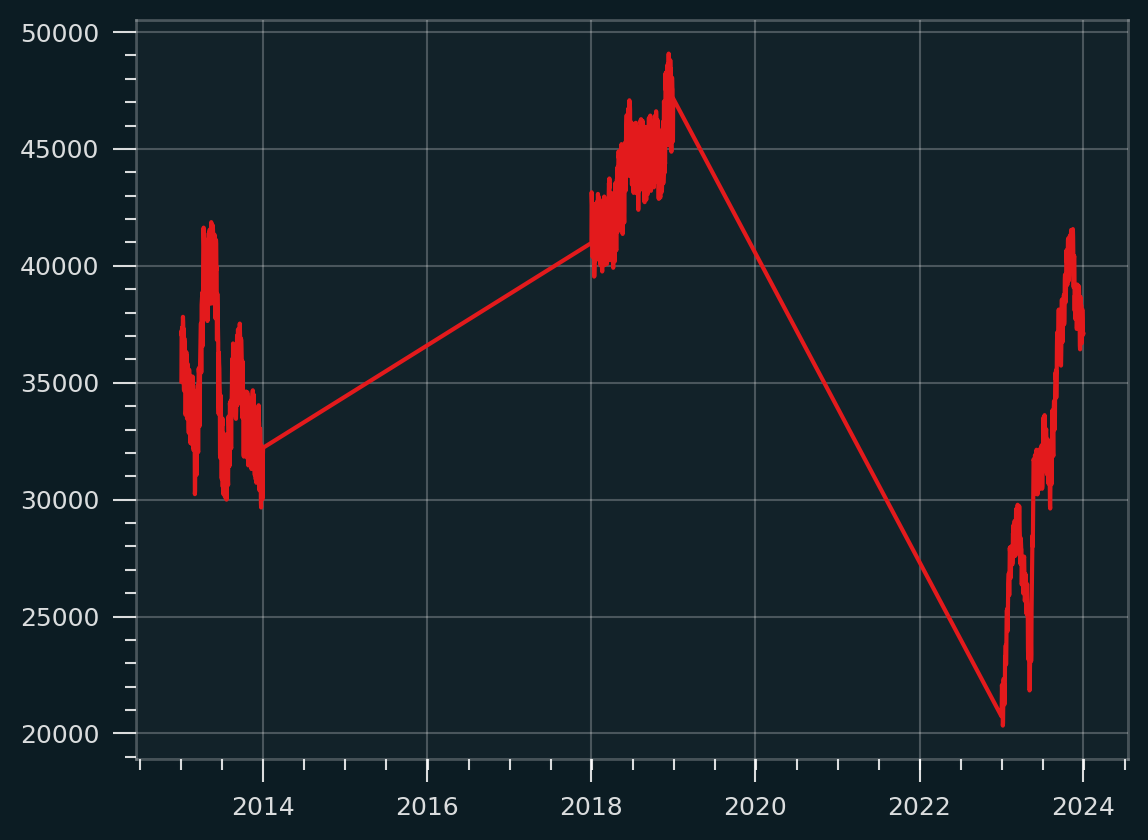

In [46]:
plt.plot(df.date, df.daily_pop)


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))  # 2 rows, 1 column

# First plot: Population Over Time (top)
axes[0].plot(
    daily_ts["date"],
    daily_ts["daily_pop"],
    label="Daily Population",
    linewidth=2,
    color="blue",
)
axes[0].plot(
    daily_ts["date"],
    daily_ts["midnight_pop"],
    label="Daily Midnight Population",
    linewidth=2,
    color="red",
    linestyle="--",
)
